# RepSeq MiXCR module DEMO 

This is a demo Jupyter notebook, showing how to use MiXCR module of RepSeq library.

Running MiXCR can be performed manually or through Platforma.bio (link) client graphical interface.

I prefer using Jupyter Notebooks for all my analyzes because they can be seen as Digital Lab Journals with all the timestamps, headers and resulting tables and plots.
Here you can prepare all your samples metadata, list all the fastq files, make a MiXCR command template and run all the samples using this command in a batch without editing any scripts and creating difficult commands.
Most modern computational clusters support SLURM queue manager and this backend type is taken care of.


**Main functions of the module**

- `mixcr4_analyze_batch` - runs MiXCR 4 in batch mode for a bunch of samples through SLURM (in parallel jobs) or just locally one by one
- `check_batch_progress` - function for checking of batch analysis progress (progress bar)
- `mixcr4_reports` - runs main MiXCR exportQc subprocesses for a given folder with MiXCR outputs
- `show_report_images` - prints the results of the `mixcr4_reports` to the Jupyter cell output
- `show_qc_plot` - makes our custom plots similar to MiXCR exportQc plots
- `get_processing_table` - creates a table with useful preprocessing statistics


**The computational pipeline of `mixcr4_analyze_batch` requires you to specify the following things:**
- sample table (in form of pandas DataFrame), specifying the list of samples to preprocess with MiXCR: their sample_id, full paths to R1 and R2 fastq files.
- path to your MiXCR executable (latest version is 4.7.0). Make sure you've got the licence
- output folder
- MiXCR command template (by default the "milab-human-rna-tcr-umi-multiplex" preset will be used - most popular in our lab)
- required resources (memory, cpu)

# Preparations 

## Imports

### Basic imports

In [1]:
import os
import pandas as pd
from pandas.api.types import CategoricalDtype

### RepSeq import

In [2]:
from repseq import mixcr as mx
from repseq import io as repseqio
from repseq import plot as rsplot

In [3]:
import importlib
importlib.reload(mx)

<module 'repseq.mixcr' from '/home/mmyshkin/soft/repseq/repseq/mixcr.py'>

## Path to MiXCR binary

In [15]:
MIXCR_PATH = "/home/mmyshkin/soft/mixcr/mixcr"

## Prepare sample_df

If you have a dataframe containing `sample_id`'s and corresponding full paths to `R1` and `R2` fastq files - just read it into pd.DataFrame format and rename the columns if needed 

If you don't have such a table your can use the following code example for creating this dataframe from scratch

For D.Chudakov's labs who work with CDR3net and Aldan3 servers there is special function, which reads `metadata.yaml` files from NGSiK system folders and creates the sample_df: `repseqio.read_ngsik_metadata(<path/to/folder>)`

### Create sample_df from scratch

In [4]:
RAW_DATA_DIR = "/home/mmyshkin/projects/repseq/test_mixcr_data/"

# find all files containing "R1" in their name - you can tweak the substring to match your files.
# The R1 requirement lists only one of the two files so you have a single entry for each sample
filenames = [f for f in os.listdir(RAW_DATA_DIR) if "R1" in f]

# create dataframe with R1 filenames
sample_df = pd.DataFrame(filenames, columns=["R1"])

# parse the sample_id's from R1 samples by splitting and connecting '_' underscores
sample_df["sample_id"] = sample_df["R1"].apply(lambda x: "_".join(x.split("_")[:2]))

# make full path from R1 filename
sample_df["R1"] = sample_df["R1"].apply(lambda x: os.path.join(RAW_DATA_DIR, x))

# make full path to R2 by replacing
sample_df["R2"] = sample_df["R1"].apply(lambda x: x.replace("_R1_", "_R2_"))

# subset columns if needed
sample_df = sample_df[["sample_id", "R1", "R2"]]

# extract donor ID from sample_id
sample_df["donor"] = sample_df["sample_id"].apply(lambda x: x.split("_")[0])

sample_df

,sample_id,R1,R2,donor
0,UCB1_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB1
1,UCB6_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB6
2,UCB5_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB5
3,UCB13_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB13
4,UCB3_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB3
5,UCB9_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB9
6,UCB11_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB11
7,UCB2_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB2
8,UCB4_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB4
9,UCB8_nCD8,/home/mmyshkin/projects/repseq/test_mixcr_data...,/home/mmyshkin/projects/repseq/test_mixcr_data...,UCB8


In [17]:
donor_group = pd.read_csv("/home/mmyshkin/projects/repseq/test_mixcr_data/ucb_metadata.csv")
donor_group

,donor,experimental_group
0,UCB1,preterm
1,UCB2,term
2,UCB3,term
3,UCB4,late
4,UCB5,preterm
5,UCB6,term
6,UCB7,late
7,UCB8,late
8,UCB9,late
9,UCB10,term


In [26]:
exp_group_order = CategoricalDtype(categories=['preterm', 'term', 'late', 'children', 'adults', 'older_adults'], ordered=True)

metadata = sample_df.drop(columns=["R1", "R2"])
metadata = metadata.merge(donor_group)
metadata["experimental_group"] = metadata["experimental_group"].astype(exp_group_order)
metadata

,sample_id,donor,experimental_group
0,UCB1_nCD8,UCB1,preterm
1,UCB6_nCD8,UCB6,term
2,UCB5_nCD8,UCB5,preterm
3,UCB13_nCD8,UCB13,term
4,UCB3_nCD8,UCB3,term
5,UCB9_nCD8,UCB9,late
6,UCB11_nCD8,UCB11,preterm
7,UCB2_nCD8,UCB2,term
8,UCB4_nCD8,UCB4,late
9,UCB8_nCD8,UCB8,late


## Create working directory and give name to `output_dir`

In [5]:
WORKING_DIR = "/home/mmyshkin/projects/repseq/"
MIXCR_DIR_SLURM = os.path.join(WORKING_DIR, "mixcr_test_output")
MIXCR_DIR_LOCAL = os.path.join(WORKING_DIR, "mixcr_test_output_l")

In [ ]:
# creates directory if it doesn't exist
os.makedirs(WORKING_DIR, exist_ok=True)

## Make up MiXCR command template

**Be careful creating these templates!**

1. `mixcr`, `analyze`, `r1`, `r2`, `output_prefix` - are **magical** words that should not be touched. You can only change everything in between
2. you should not add parameter like `-Xmx16g` which asks Java Virtual Machine to utilize this amount of RAM, as it is dealt with in the main function and you can pass your custom value there
3. Reference this page for creating your commands https://mixcr.com/mixcr/reference/mixcr-analyze/#command-line-options
4. Reference this page for selecting built-in presets https://mixcr.com/mixcr/reference/overview-built-in-presets/
5. Some examples of common commands in our lab are listed below

For this dataset we used `LLC MiLaboratory 5'RACE TCR Kit Human` and here is the command template for it (`-f` is useful flag for rerunning your preprocessing):

In [10]:
mixcr_race_command_template = "mixcr analyze milab-human-rna-tcr-umi-race -f r1 r2 output_prefix"

# RUN! MiXCR

Now that we have prepared everything: `sample_df`, `MIXCR_PATH`, `MIXCR_DIR_SLURM`, `mixcr_race_command_template`

We can now run MiXCR!

## Using SLURM queue manager

Our computational cluster Aldan3 (link) uses SLURM queue manager. So the first part of the demo will be useful for SLURM users

The following function in its core constructs a MiXCR command for each sample and then automatically creates SLURM .sh scripts for each of the samples so they can be processed in parallel on different nodes. It adds all the given resources requirements to the SLURM script. Then adds all these SLURM jobs to the queue with `sbatch` command.

The scripts are kept in `~/temp/slurm/` folder and have timestamps as well as job_names in their names.

The log files with stdout/stderr MiXCR output can be found in your `output_folder/logs` directory. Check them in case something goes wrong.

In [11]:
mx.mixcr4_analyze_batch(sample_df,                                        # <- first arg is your sample df. Make sure it contains sample_id, R1 and R2 (full paths) columns 
                        MIXCR_DIR_SLURM,                                  # <- second arg is output folder (also better use abs path)
                        mixcr_path=MIXCR_PATH,                            # <- path to MIXCR binary
                        command_template=mixcr_race_command_template,     # <- your command template variable. Default is "mixcr analyze milab-human-rna-tcr-umi-multiplex -f r1 r2 output_prefix"
                        backend="slurm",                                  # <- type of backend "slurm" or "local", "local" is default value
                        cpus=40,                                          # <- CPU's - will be added to SLURM .sh script
                        memory=32,                                        # <- RAM in Gb's. Also will be added to SLURM .sh script and -Xmx32g to mixcr command so that Java takes this memory
                        time_estimate=1.5,                                # <- time in hours - will be added to SLURM .sh script
                        custom_tag_pattern_column=None                    # <- If your df contains valid custom tag-patterns for each sample it can be uppended to the command template automatically
                       )

13 tasks added to slurm queue
Logs folder: /home/mmyshkin/projects/repseq/mixcr_test_output/logs
Job table: /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_batch_jobs.csv


,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_UCB10_nCD8,UCB10_nCD8,slurm,1416799,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
1,mixcr_analyze_UCB11_nCD8,UCB11_nCD8,slurm,1416795,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
2,mixcr_analyze_UCB12_nCD8,UCB12_nCD8,slurm,1416800,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
3,mixcr_analyze_UCB13_nCD8,UCB13_nCD8,slurm,1416792,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
4,mixcr_analyze_UCB1_nCD8,UCB1_nCD8,slurm,1416789,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
5,mixcr_analyze_UCB2_nCD8,UCB2_nCD8,slurm,1416796,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
6,mixcr_analyze_UCB3_nCD8,UCB3_nCD8,slurm,1416793,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
7,mixcr_analyze_UCB4_nCD8,UCB4_nCD8,slurm,1416797,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
8,mixcr_analyze_UCB5_nCD8,UCB5_nCD8,slurm,1416791,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
9,mixcr_analyze_UCB6_nCD8,UCB6_nCD8,slurm,1416790,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...


**Check the progress!**

With `loop=True` this function once a second checks the status of the appended jobs from the function above through `sacct` command which assessed job status from SLURM queue.

All the stats and job names+ID's are kept in the `mixcr_analyze_batch.log` file in your `output_folder` (`MIXCR_DIR_SLURM` in this case). This file is completely rewritten each time you run `mx.mixcr4_analyze_batch()`

In [12]:
mx.check_batch_progress(MIXCR_DIR_SLURM, loop=True)

MIXCR4 Analyze Batch |##################################################| 13/13 task(s) processed


With `loop=False` this function just instantly shows the current state of the progress

In [33]:
mx.check_batch_progress(MIXCR_DIR_SLURM, loop=False)

                 jobname  sample_id backend  job_id   status  returncode                                                                       log_filename
 mixcr_analyze_UCB1_nCD8  UCB1_nCD8   slurm 1416382 finished           0  /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_UCB1_nCD8.log
 mixcr_analyze_UCB6_nCD8  UCB6_nCD8   slurm 1416383 finished           0  /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_UCB6_nCD8.log
 mixcr_analyze_UCB5_nCD8  UCB5_nCD8   slurm 1416384 finished           0  /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_UCB5_nCD8.log
mixcr_analyze_UCB13_nCD8 UCB13_nCD8   slurm 1416385 finished           0 /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_UCB13_nCD8.log
 mixcr_analyze_UCB3_nCD8  UCB3_nCD8   slurm 1416386 finished           0  /home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_UCB3_nCD8.log
 mixcr_analyze_UCB9_nCD8  UCB9_nCD8   slurm 1416387 finished    

The state of all jobs can be checked in this file `logs/mixcr_analyze_batch_jobs.csv`. The jobnames that are rerun are updated in this file, while other are kept intact.

This is useful to check how did everything go and how all the jobs were submitted to the queue.

In [36]:
pd.read_csv("/home/mmyshkin/projects/repseq/mixcr_test_output/logs/mixcr_analyze_batch_jobs.csv")

,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_UCB1_nCD8,UCB1_nCD8,slurm,1416382,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
1,mixcr_analyze_UCB6_nCD8,UCB6_nCD8,slurm,1416383,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
2,mixcr_analyze_UCB5_nCD8,UCB5_nCD8,slurm,1416384,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
3,mixcr_analyze_UCB13_nCD8,UCB13_nCD8,slurm,1416385,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
4,mixcr_analyze_UCB3_nCD8,UCB3_nCD8,slurm,1416386,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
5,mixcr_analyze_UCB9_nCD8,UCB9_nCD8,slurm,1416387,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
6,mixcr_analyze_UCB11_nCD8,UCB11_nCD8,slurm,1416388,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
7,mixcr_analyze_UCB2_nCD8,UCB2_nCD8,slurm,1416389,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
8,mixcr_analyze_UCB4_nCD8,UCB4_nCD8,slurm,1416390,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
9,mixcr_analyze_UCB8_nCD8,UCB8_nCD8,slurm,1416391,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...


## Running in `local` mode without queue manager

Here we will use a different folder for the output

In [38]:
MIXCR_DIR_LOCAL

'/home/mmyshkin/projects/repseq/mixcr_test_output_l'

In `local` mode the function creates commands for each of the samples and runs them sequentially one by one and showing the progress bar.

Wait for the function to finish... It may take a while.

In [39]:
mx.mixcr4_analyze_batch(sample_df,                                        # <- first arg is your sample df. Make sure it contains sample_id, R1 and R2 (full paths) columns 
                        MIXCR_DIR_LOCAL,                                  # <- second arg is output folder (also better use abs path)
                        mixcr_path=MIXCR_PATH,                            # <- path to MIXCR binary
                        command_template=mixcr_race_command_template,     # <- your command template variable. Default is "mixcr analyze milab-human-rna-tcr-umi-multiplex -f r1 r2 output_prefix"
                        backend="local",                                  # <- type of backend "slurm" or "local", "local" is default value
                        cpus=2,                                           # <- CPU's - will be added to SLURM .sh script
                        memory=8,                                         # <- RAM in Gb's. Also will be added to SLURM .sh script and -Xmx32g to mixcr command so that Java takes this memory
                        time_estimate=1.5,                                # <- time in hours - will be added to SLURM .sh script
                        custom_tag_pattern_column=None                    # <- If your df contains valid custom tag-patterns for each sample it can be uppended to the command template automatically
                       )

8 < than limit (16), using 16 GB
MIXCR4 Analyze Batch |##################################################| 13/13 task(s) processed
Logs folder: /home/mmyshkin/projects/repseq/mixcr_test_output_l/logs
Job table: /home/mmyshkin/projects/repseq/mixcr_test_output_l/logs/mixcr_analyze_batch_jobs.csv


,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_UCB10_nCD8,UCB10_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
1,mixcr_analyze_UCB11_nCD8,UCB11_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
2,mixcr_analyze_UCB12_nCD8,UCB12_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
3,mixcr_analyze_UCB13_nCD8,UCB13_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
4,mixcr_analyze_UCB1_nCD8,UCB1_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
5,mixcr_analyze_UCB2_nCD8,UCB2_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
6,mixcr_analyze_UCB3_nCD8,UCB3_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
7,mixcr_analyze_UCB4_nCD8,UCB4_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
8,mixcr_analyze_UCB5_nCD8,UCB5_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
9,mixcr_analyze_UCB6_nCD8,UCB6_nCD8,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...


After the run the state of all jobs can be checked in this file `logs/mixcr_analyze_batch_jobs.csv`. The jobnames that are rerun are updated in this file, while other are kept intact.

This is useful to check how did everything go

In [41]:
pd.read_csv("/home/mmyshkin/projects/repseq/mixcr_test_output_l/logs/mixcr_analyze_batch_jobs.csv")

,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_UCB1_nCD8,UCB1_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
1,mixcr_analyze_UCB6_nCD8,UCB6_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
2,mixcr_analyze_UCB5_nCD8,UCB5_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
3,mixcr_analyze_UCB13_nCD8,UCB13_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
4,mixcr_analyze_UCB3_nCD8,UCB3_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
5,mixcr_analyze_UCB9_nCD8,UCB9_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
6,mixcr_analyze_UCB11_nCD8,UCB11_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
7,mixcr_analyze_UCB2_nCD8,UCB2_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
8,mixcr_analyze_UCB4_nCD8,UCB4_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...
9,mixcr_analyze_UCB8_nCD8,UCB8_nCD8,local,NaN,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx16g analyz...


# Quality control

## QC images by MiXCR

These functions run MiXCR `mixcr exportQc` subcommands in three regimes (5 runs total):
- align (export svg + pdf)
- chainUsage (export svg + pdf)
- tags (pdf only)

`svg` versions are easier to show inside the Jupyter Notebooks and are not as 'heavy' as `png`.

The `pdf` versions are easier to share with collegues and show in different reports. Also we usually do not look at tagsQc in the Jupyter as these files are quite big.

### SLURM mode

In [14]:
mx.mixcr4_reports(MIXCR_DIR_SLURM, mixcr_path=MIXCR_PATH, backend="slurm")

5 tasks added to slurm queue
Logs folder: /home/mmyshkin/projects/repseq/mixcr_test_output/logs
Batch log: /home/mmyshkin/projects/repseq/mixcr_test_output/mixcr_reports_slurm_batch.log


,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,alignQc,,slurm,1416783,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
1,alignQcPDF,,slurm,1416785,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
2,chainUsage,,slurm,1416784,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
3,chainUsagePDF,,slurm,1416786,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
4,tagsQc,,slurm,1416787,submitted,,/home/mmyshkin/projects/repseq/mixcr_test_output,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...


You can also track the progress of SLURM jobs here. But usually these jobs do not take much time

In [15]:
mx.check_batch_progress(MIXCR_DIR_SLURM, default_filename="mixcr_reports_slurm_batch.log", loop=True)

MiXCR 4 Reports |##################################################| 5/5 task(s) processed


In [7]:
mx.check_batch_progress(MIXCR_DIR_SLURM, default_filename="mixcr_reports_slurm_batch.log", loop=False)

      jobname sample_id backend  job_id   status  returncode                                                            log_filename
      alignQc             slurm 1416555 finished           0       /home/mmyshkin/projects/repseq/mixcr_test_output/logs/alignQc.log
   chainUsage             slurm 1416556 finished           0    /home/mmyshkin/projects/repseq/mixcr_test_output/logs/chainUsage.log
   alignQcPDF             slurm 1416557 finished           0    /home/mmyshkin/projects/repseq/mixcr_test_output/logs/alignQcPDF.log
chainUsagePDF             slurm 1416558 finished           0 /home/mmyshkin/projects/repseq/mixcr_test_output/logs/chainUsagePDF.log
       tagsQc             slurm 1416559 finished           0        /home/mmyshkin/projects/repseq/mixcr_test_output/logs/tagsQc.log
MIXCR4.3 Reports |##################################################| 5/5 task(s) processed


### Local mode

In [7]:
mx.mixcr4_reports(MIXCR_DIR_LOCAL, mixcr_path=MIXCR_PATH, backend="local")

MiXCR 4 Reports |##################################################| 5/5 task(s) processed
Logs folder: /home/mmyshkin/projects/repseq/mixcr_test_output_l/logs
Batch log: /home/mmyshkin/projects/repseq/mixcr_test_output_l/mixcr_reports_slurm_batch.log


,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,alignQc,,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
1,alignQcPDF,,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
2,chainUsage,,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
3,chainUsagePDF,,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...
4,tagsQc,,local,,finished,0,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/projects/repseq/mixcr_test_outp...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g export...


### Show the images

This function finds the `alignQc` and `chainQc` files (in `svg` or `png` formats) and plots them out

/home/mmyshkin/projects/repseq/mixcr_test_output/alignQc.svg


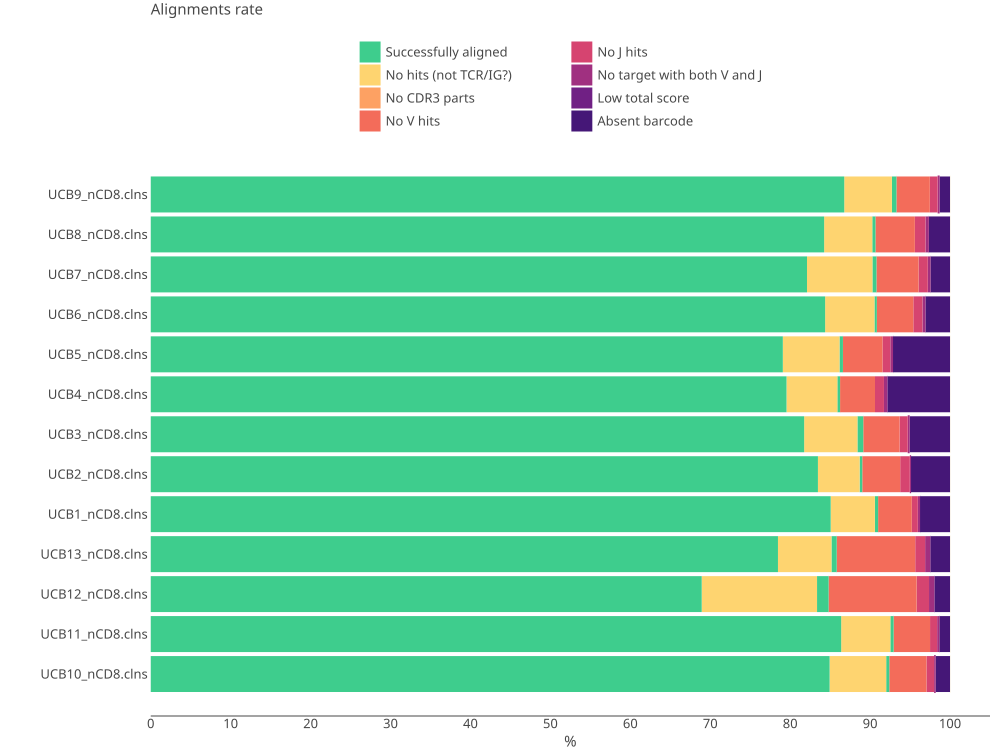

/home/mmyshkin/projects/repseq/mixcr_test_output/chainsQc.svg


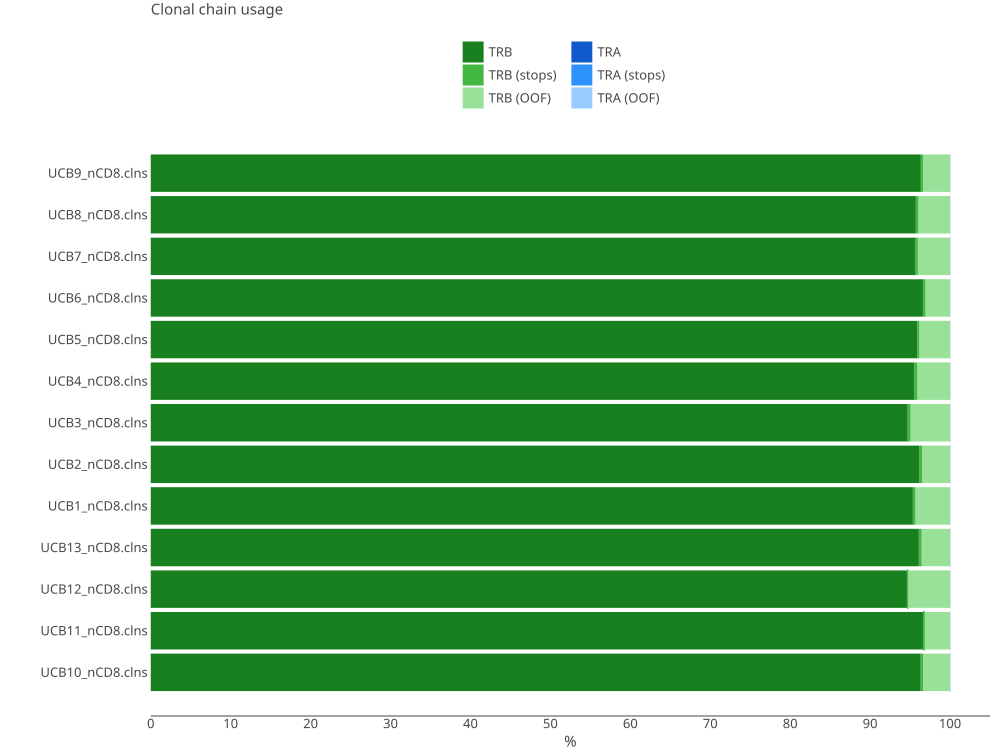

In [29]:
mx.show_report_images(MIXCR_DIR_SLURM)

## QC images by Repseq - analogs, that are read from `report.json` files

Sometimes the MiXCR report images contain bugs and the bugs are not yet fixed in v4.7.0.

So we've made our own functions that scrape `reports.json` files and make the same plots with `matplotlib`

### Align QC

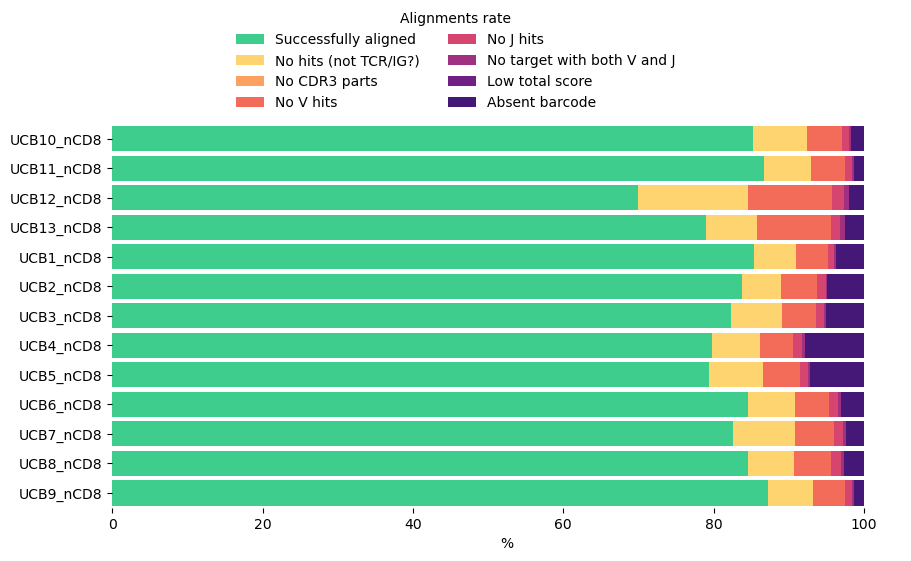

In [9]:
mx.show_qc_plot(MIXCR_DIR_SLURM, chart_type='align', count_type='percent', output_file=None)

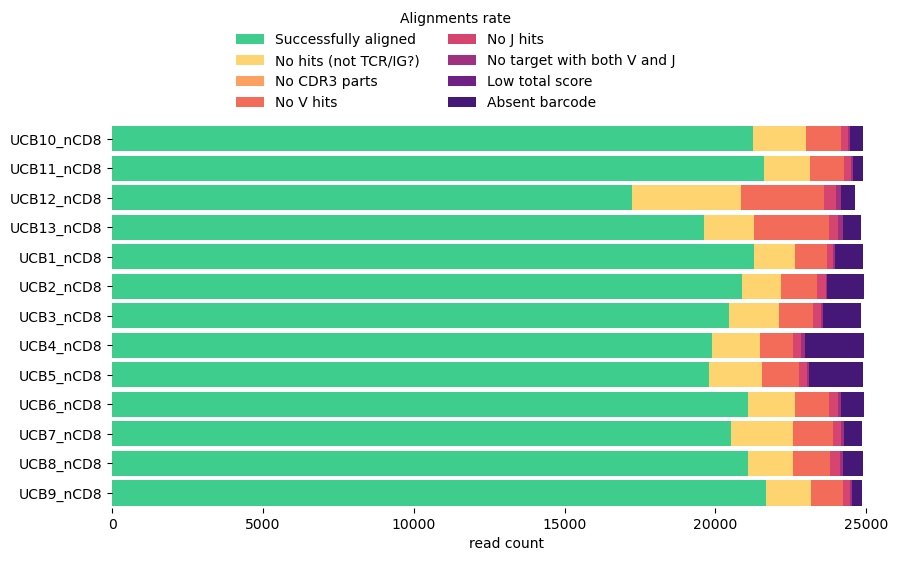

In [10]:
mx.show_qc_plot(MIXCR_DIR_SLURM, chart_type='align', count_type='abs', output_file=None)

### Chain QC

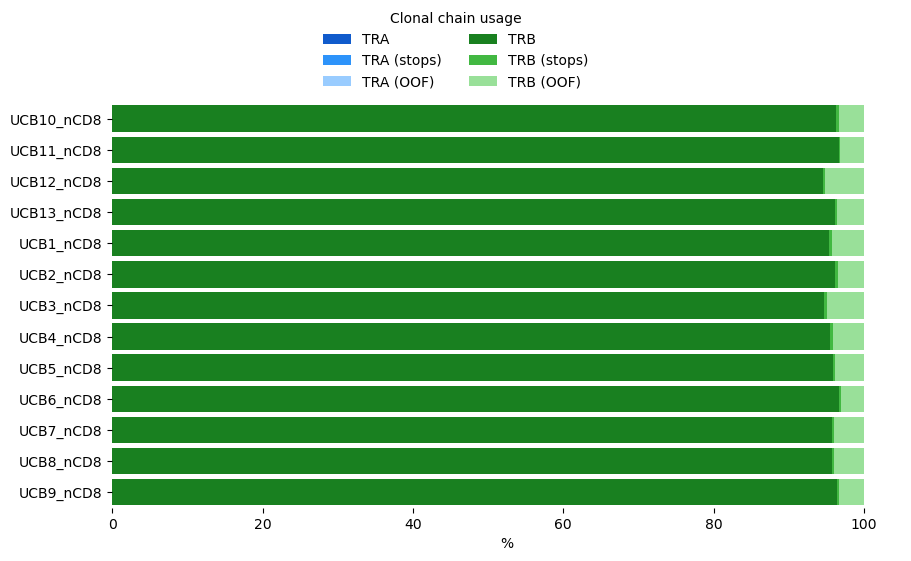

In [6]:
mx.show_qc_plot(MIXCR_DIR_SLURM, chart_type='chains', count_type='percent', output_file=None)

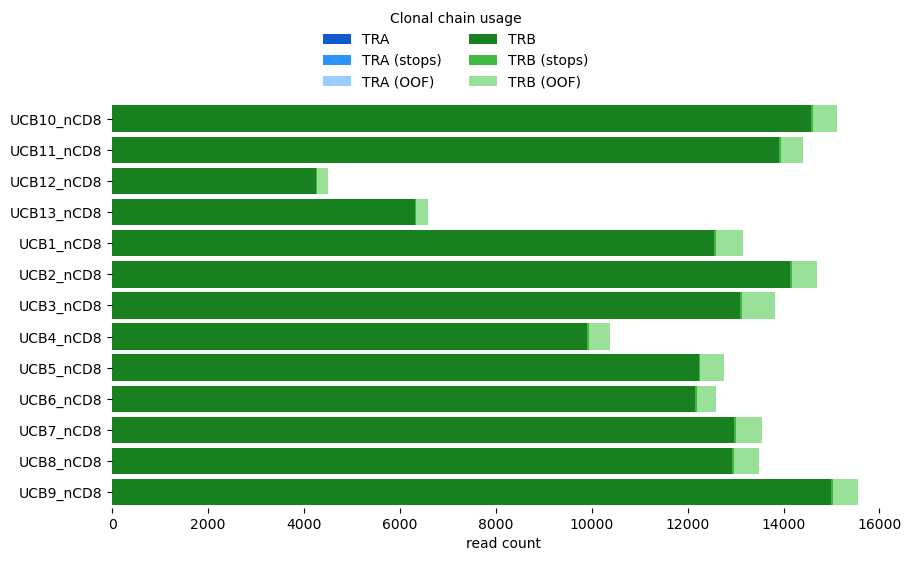

In [7]:
mx.show_qc_plot(MIXCR_DIR_SLURM, chart_type='chains', count_type='abs', output_file=None)

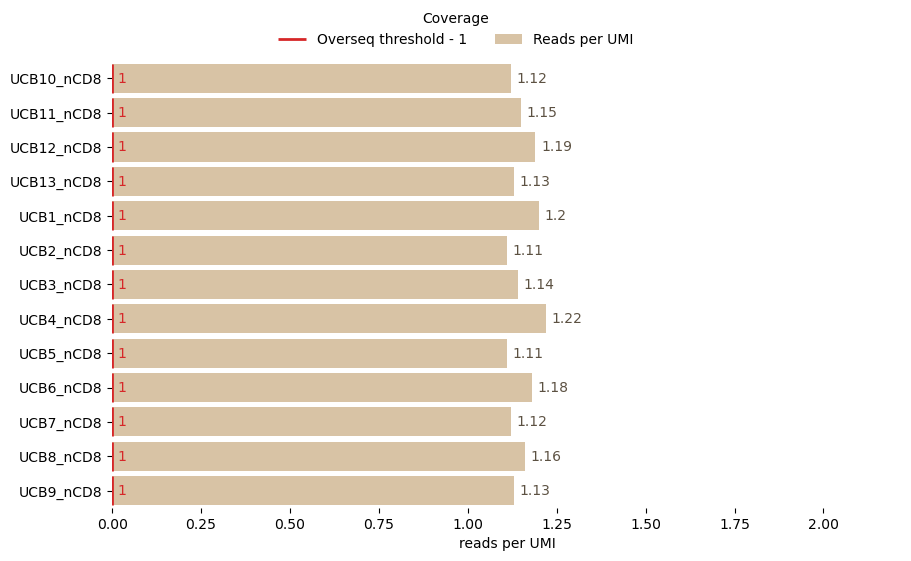

In [33]:
mx.show_qc_plot(MIXCR_DIR_SLURM, chart_type='coverage', count_type='abs', output_file=None)

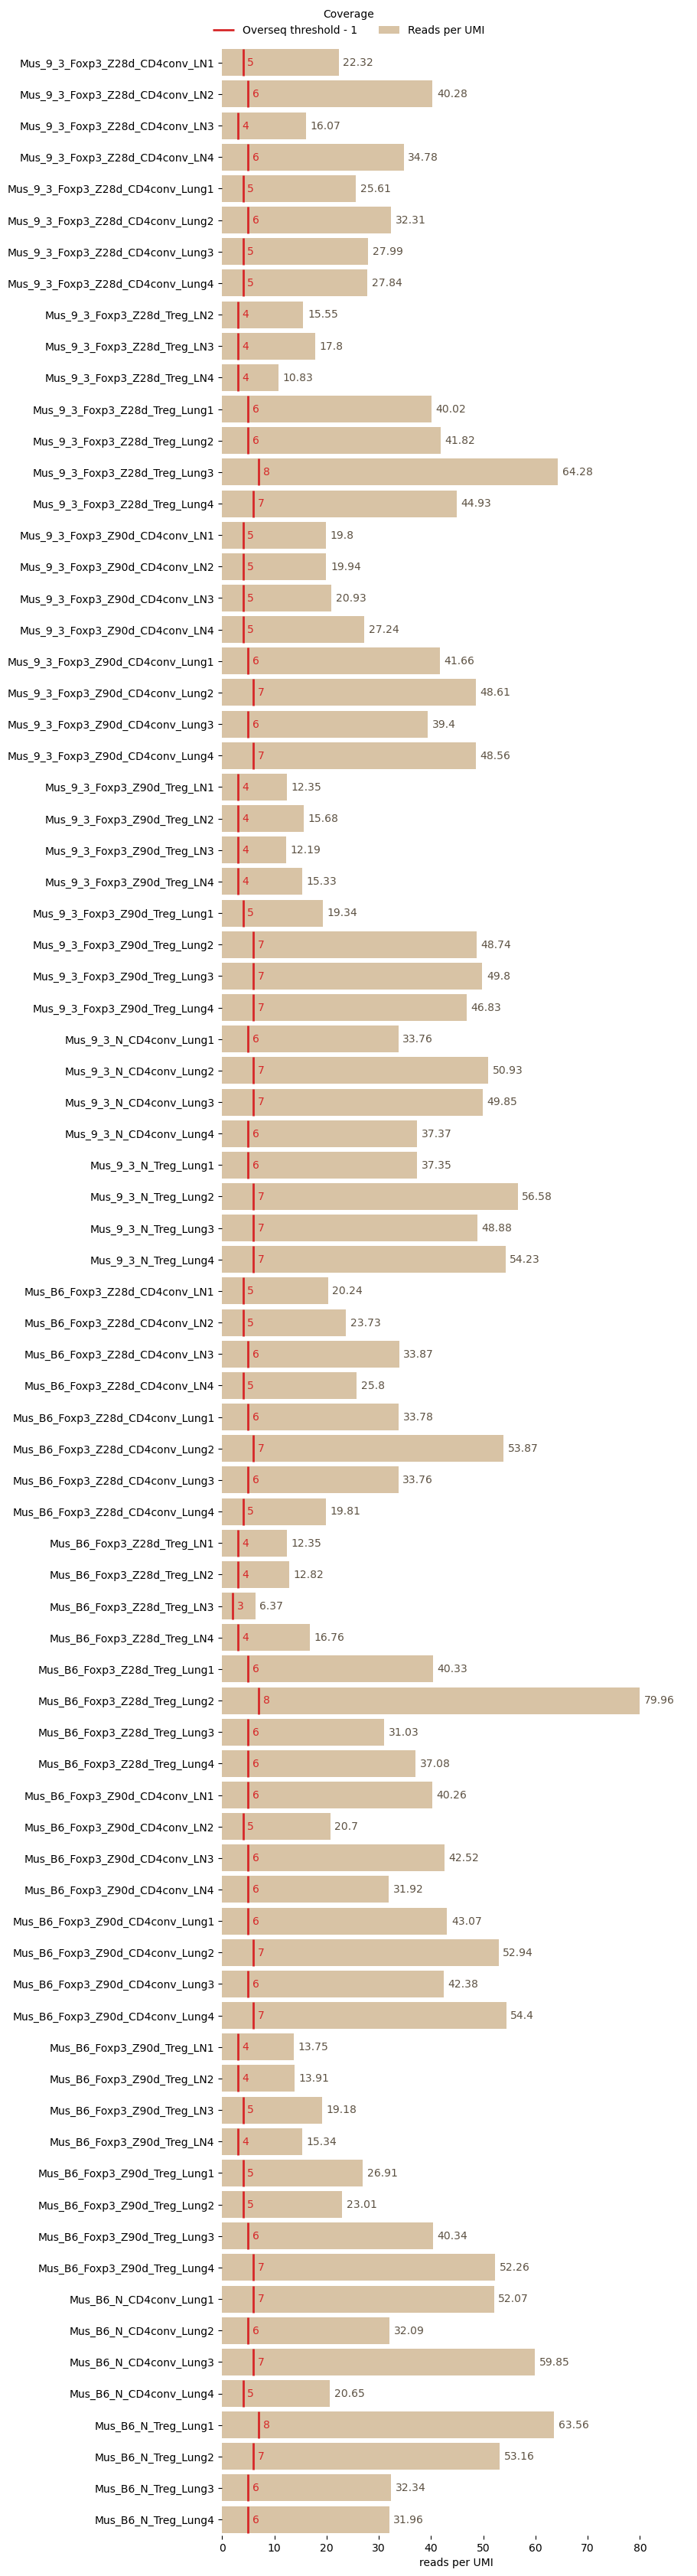

In [34]:
mx.show_qc_plot("/projects/placenta_sc/mice_tb/mixcr/", chart_type='coverage', count_type='abs', output_file=None)

## Comprehensive Preprocessing Table

It is very useful to glance at the main preprocessing metrics that show
- how the samples were sequenced
- how good the alignment process went
- what is the coverage of your raw data (reads/UMI)
- how many clonotypes have you got

The following function scrapes `report.json` files for the most useful metrics among all possible that we look at in our lab.

You can save it to `csv` and share it with collegues and add it to our paper supplementary materials

### Get the table

In [20]:
proc_table = mx.get_processing_table(MIXCR_DIR_SLURM)
proc_table

,sample_id,extracted_chain,reads_total,reads_with_umi_pc,reads_aligned_pc,reads_overlapped_aln_pc,total_umi,umi_after_correction,overseq_threshold,reads_after_filter,umi_after_filter,reads_per_umi,clones_total,reads_in_clones_total,clones,reads_in_clones,clones_func,reads_in_func_clones,umi_in_clones,umi_in_func_clones
0,UCB10_nCD8,TRB,25000,98.20,84.93,3.89,18998,18937,1,21207,18937,1.12,15119,18524,15119,18524,14563,17879,16385,15823
1,UCB11_nCD8,TRB,25000,98.66,86.38,3.12,18882,18828,1,21577,18828,1.15,14401,19192,14401,19192,13913,18613,16546,16043
2,UCB12_nCD8,TRB,25000,98.04,68.93,11.87,14563,14450,1,17233,14450,1.19,4501,7879,4501,7879,4258,7450,5436,5174
3,UCB13_nCD8,TRB,25000,97.53,78.47,5.24,17446,17393,1,19617,17393,1.13,6579,9771,6579,9771,6322,9435,7766,7497
4,UCB1_nCD8,TRB,25000,96.24,85.07,3.15,17959,17722,1,21244,17722,1.20,13156,19192,13155,19191,12544,18401,15751,15106
5,UCB2_nCD8,TRB,25000,95.12,83.47,2.35,18890,18711,1,20850,18711,1.11,14691,18234,14691,18234,14129,17588,16210,15627
6,UCB3_nCD8,TRB,25000,94.94,81.75,6.60,18035,17877,1,20426,17877,1.14,13821,18097,13821,18097,13088,17221,15633,14878
7,UCB4_nCD8,TRB,25000,92.16,79.54,3.97,16696,16351,1,19871,16351,1.22,10374,17918,10374,17918,9909,17258,14452,13927
8,UCB5_nCD8,TRB,25000,92.86,79.08,4.57,18021,17779,1,19756,17779,1.11,12753,17709,12752,17708,12231,17098,15755,15206
9,UCB6_nCD8,TRB,25000,96.93,84.37,2.33,17879,17815,1,21086,17815,1.18,12586,18313,12585,18312,12159,17796,15157,14712


### A smaller table (just a subset)

You also can subset a smaller even more useful subset of metrics here:

In [6]:
mx.get_processing_table(MIXCR_DIR_SLURM, small=True)

,sample_id,extracted_chain,reads_total,reads_with_umi_pc,reads_aligned_pc,reads_overlapped_aln_pc,reads_per_umi,overseq_threshold,clones_func,umi_in_func_clones
0,UCB10_nCD8,TRB,25000,98.20,84.93,3.89,1.12,1,14563,15823
1,UCB11_nCD8,TRB,25000,98.66,86.38,3.12,1.15,1,13913,16043
2,UCB12_nCD8,TRB,25000,98.04,68.93,11.87,1.19,1,4258,5174
3,UCB13_nCD8,TRB,25000,97.53,78.47,5.24,1.13,1,6322,7497
4,UCB1_nCD8,TRB,25000,96.24,85.07,3.15,1.20,1,12544,15106
5,UCB2_nCD8,TRB,25000,95.12,83.47,2.35,1.11,1,14129,15627
6,UCB3_nCD8,TRB,25000,94.94,81.75,6.60,1.14,1,13088,14878
7,UCB4_nCD8,TRB,25000,92.16,79.54,3.97,1.22,1,9909,13927
8,UCB5_nCD8,TRB,25000,92.86,79.08,4.57,1.11,1,12231,15206
9,UCB6_nCD8,TRB,25000,96.93,84.37,2.33,1.18,1,12159,14712


### Dealing with offtarget chains

**Important!**

You may notice that the number of clonosets found in the folder is bigger than in the number in the table above.

This is because there can be small contaminations of the neighbouring chains in the libraries.

In this dataset we made TRA+TRB separate libraries for each of the samples, so here is the small contamination of TRA chains in these TRB libraries:

You can toggle to `show_offtarget=True` chains to see them all. But in most cases it is useful to hide all these contaminations.

You also can leave `show_offtarget=False` and tweak `offtarget_chain_threshold` that is counted as a `reads_in_clones` fraction for a given chain for the whole sample.

In [55]:
mx.get_processing_table(MIXCR_DIR_SLURM,
                        show_offtarget=True,
                        offtarget_chain_threshold=0.01
                       )

,sample_id,extracted_chain,reads_total,reads_with_umi_pc,reads_aligned_pc,reads_overlapped_aln_pc,total_umi,umi_after_correction,overseq_threshold,reads_after_filter,umi_after_filter,reads_per_umi,clones_total,reads_in_clones_total,clones,reads_in_clones,clones_func,reads_in_func_clones,umi_in_clones,umi_in_func_clones
0,UCB10_nCD8,TRB,25000,98.20,84.93,3.89,18998,18937,1,21207,18937,1.12,15119,18524,15119,18524,14563,17879,16385,15823
1,UCB11_nCD8,TRB,25000,98.66,86.38,3.12,18882,18828,1,21577,18828,1.15,14401,19192,14401,19192,13913,18613,16546,16043
2,UCB12_nCD8,TRB,25000,98.04,68.93,11.87,14563,14450,1,17233,14450,1.19,4501,7879,4501,7879,4258,7450,5436,5174
3,UCB13_nCD8,TRB,25000,97.53,78.47,5.24,17446,17393,1,19617,17393,1.13,6579,9771,6579,9771,6322,9435,7766,7497
4,UCB1_nCD8,TRB,25000,96.24,85.07,3.15,17959,17722,1,21244,17722,1.20,13156,19192,13155,19191,12544,18401,15751,15106
5,UCB1_nCD8,TRA,25000,96.24,85.07,3.15,17959,17722,1,21244,17722,1.20,13156,19192,1,1,0,0,1,0
6,UCB2_nCD8,TRB,25000,95.12,83.47,2.35,18890,18711,1,20850,18711,1.11,14691,18234,14691,18234,14129,17588,16210,15627
7,UCB3_nCD8,TRB,25000,94.94,81.75,6.60,18035,17877,1,20426,17877,1.14,13821,18097,13821,18097,13088,17221,15633,14878
8,UCB4_nCD8,TRB,25000,92.16,79.54,3.97,16696,16351,1,19871,16351,1.22,10374,17918,10374,17918,9909,17258,14452,13927
9,UCB5_nCD8,TRA,25000,92.86,79.08,4.57,18021,17779,1,19756,17779,1.11,12753,17709,1,1,1,1,1,1


### Useful plots

Based on the preprocessing data you can plot the following QC metrics. Here's an example plot, as generally it is highly custum in each projects setup and the groups of samples. I myself make a custom plot each time.

This example is in `matplotlib`, but I prefer to use `rpy2` + `R-tidyverse` combination to make these plots, as the code is generally more readable and easier to write just from the head based on the custom sample setup.

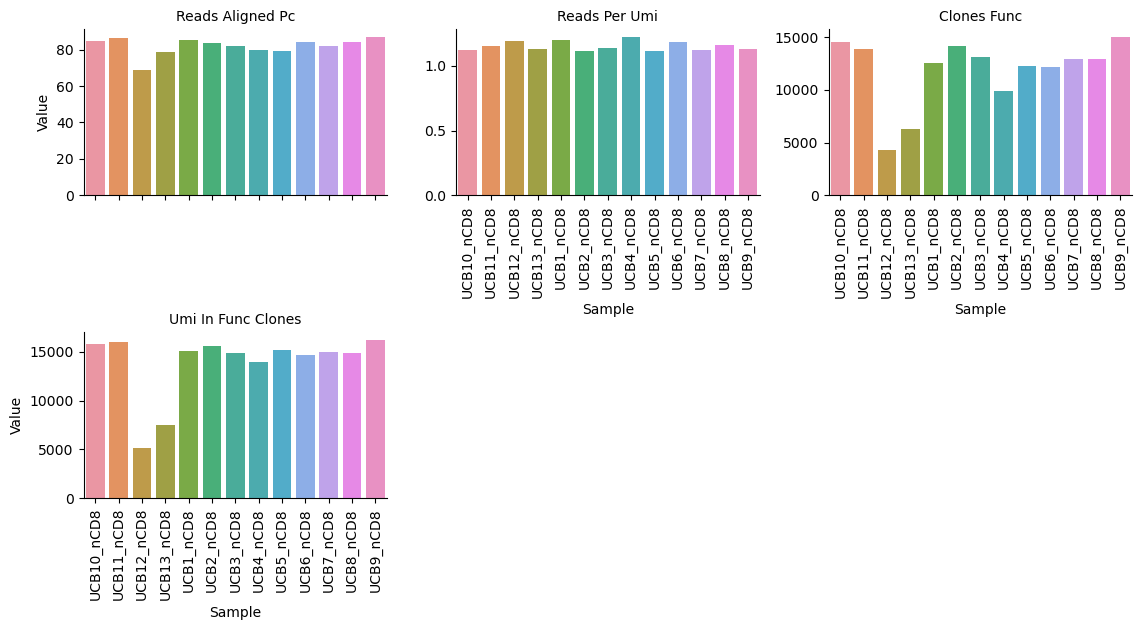

In [27]:
rsplot.processing(proc_table)

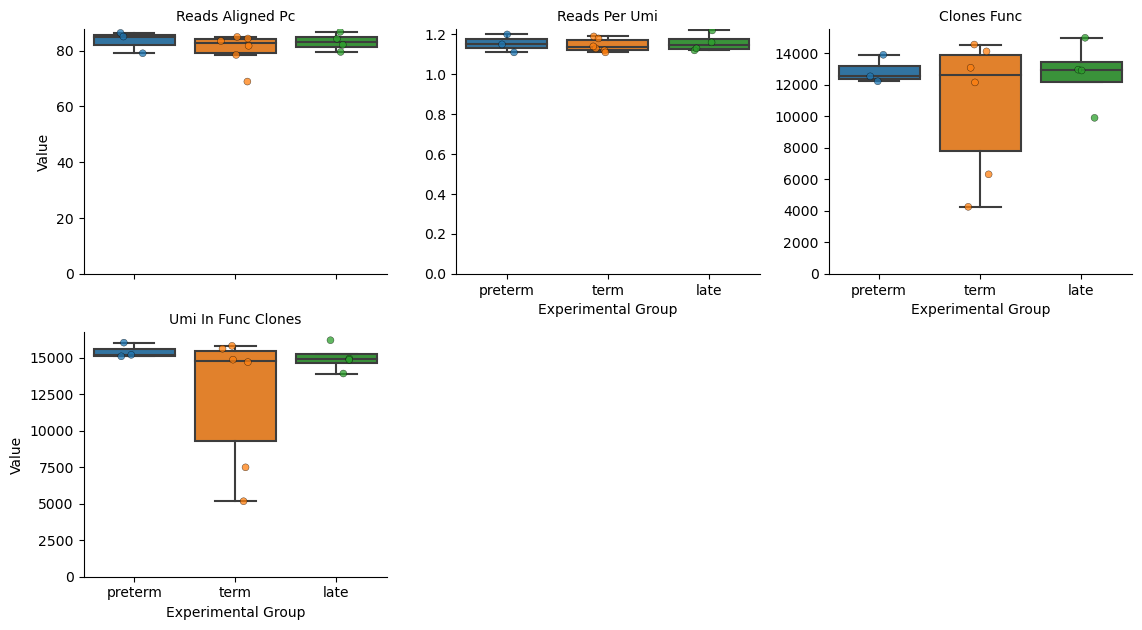

In [28]:
rsplot.processing(proc_table, metadata=metadata, group="experimental_group")

# Additional useful stuff

## Using custom tag patterns

Some users prefer to use custom sample-barcodes in addition to illumina/MGI sample indices.

In this case you can add a special column to your `sample_df` and specify it with `custom_tag_pattern_column=` option, so that `mixcr4_analyze_batch` takes individual tag-patterns for each sample and adds it properly to each MiXCR command.

Tag patterns in the cells of this column should be constructed according to special syntax explained here https://mixcr.com/mixcr/reference/ref-tag-pattern/ and look like this: `^N{0:6}tggtatcaacgcagagtAATCG(UMI:N{14})N{21}(R1:*)\^N{20}(R2:*)` (here is an example sample barcode in capitals just after the M1s adapter)

In [ ]:
mx.mixcr4_analyze_batch(sample_df,                                      # <- first arg is your sample df. Make sure it contains sample_id, R1 and R2 (full paths) columns 
                        MIXCR_DIR_CTP,                                  # <- second arg is output folder (also better use abs path)
                        mixcr_path=MIXCR_PATH,                          # <- path to MIXCR binary
                        custom_tag_pattern_column="tag_pattern"         # <- If your df contains valid custom tag-patterns for each sample it can be uppended to the command template automatically
                       )

## NGSiK `sample_df` creation (For Chudakov's labs)

At Chudakov's lab we have a special sequencing database called NGSiK. It checks and adds special metadata table for each sequencing run. We try to keep it in order instead of having metadata all over the place.

In each folder with fastq's from one particular sequencing run we have `metadata.yaml` file. And this function reads such file from the given folder and takes care of its peculiarities.

In the end you have a sample_df table with minimally required `sample_id`, `R1`, `R2` and also a bunch of columns with metadata.

You can subset this table by `projectName`, `libraryPerson` with pandas `.query()` or `.loc[]` methods and subset the columns to get only what you need.

In [11]:
from repseq import io as repseqio

repseqio.read_ngsik_metadata("/projects/cdr3_ngs/2026/02_Genomed_1491-7/")

,sample_id,R1,R2,libraryPerson,projectPerson,projectName,species,startingMaterial,libraryType,sequencingDate,sequencer,sequencingPerson,kit.sequencingKitCycles,undetermined,repSeqProtocol,Chain,Protocol,Replicas,Stimulus
0,pept_mix_p456_alpha,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRA,reactivation_Shagina,8,ApoB_p4_p5_p6
1,pept_mix_p111718_alpha,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRA,reactivation_Shagina,8,ApoB_p11_p17_p718
2,no_pept_mix_alpha,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRA,reactivation_Shagina,4,no_pept
3,pept_mix_p456_beta,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRB,reactivation_Shagina,8,ApoB_p4_p5_p6
4,pept_mix_p111718_beta,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRB,reactivation_Shagina,8,ApoB_p11_p17_p718
5,no_pept_mix_beta,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRB,reactivation_Shagina,4,no_pept
6,index_control_alpha_beta,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,/projects/cdr3_ngs/2026/02_Genomed_1491-7/Athe...,Tverdova,Britanova,Athero_ApoB_activ_assay,H.sapiens,rna,RepSeq,2026 02 17,SURFSeq5000,Grigoreva,300,False,CVAmplicon,TRA_TRB,reactivation_Shagina,0,all_stim


## Several examples of **MiXCR command templates**

### Make fixed overseq threshold

In [56]:
overseq_threshold = 2
mixcr_race_command_template_overseq2 = f"""mixcr analyze milab-human-rna-tcr-umi-race \
-Massemble.consensusAssemblerParameters.assembler.minRecordsPerConsensus={overseq_threshold} \
-MrefineTagsAndSort.parameters.postFilter=null \
--assemble-clonotypes-by CDR3  -f \
r1 r2 output_prefix"""

### MGI

Due to adapter ligation procedure during MGI library preparation the reads are directed randomly so tag-patterns should be mapped both sides with `-Malign.tagUnstranded=true` flag

Also there's additional fragment of the adapter in the reads so we need to take care of it with `^N{0:6}`. If the mapping is still low, you can enlarge the adapter length a bit to `^N{0:9}`


In [ ]:
mixcr_thrm_mgi_command = 'mixcr analyze milab-human-rna-tcr-umi-multiplex -f --tag-pattern "^N{0:6}tggtatcaacgcagagt(UMI:N{14})N{21}(R1:*)\^N{20}(R2:*)" -Malign.tagUnstranded=true r1 r2 output_prefix'

### Alpaca kit

Some commands we used for alpaca kits based on already existing mouse presets

In [8]:
ALPACA_RACE_COMMAND_VDJ = 'mixcr analyze milab-mouse-rna-tcr-umi-race -f --species alpaca --assemble-clonotypes-by VDJRegion r1 r2 output_prefix'